In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv("../../data/ECG5000_TRAIN.tsv",sep='\t',header=None)
test_data = pd.read_csv("../../data/ECG5000_TEST.tsv",sep='\t',header=None)

In [3]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,1,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,1,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,1,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,1,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456


There's 5 classes

In [4]:
train_data[0].value_counts()

0
1    292
2    177
4     19
3     10
5      2
Name: count, dtype: int64

In [5]:
test_data[0].value_counts()

0
1    2627
2    1590
4     175
3      86
5      22
Name: count, dtype: int64

In [6]:
train_data.shape

(500, 141)

In [7]:
test_data.shape

(4500, 141)

Looks like they are labelled wrong...
- test data has more instances than the train data
- will use the test data for training and the train data for testing

Visualising the data
- using test_data for exploration
- looking for how waveforms of the different classes differ

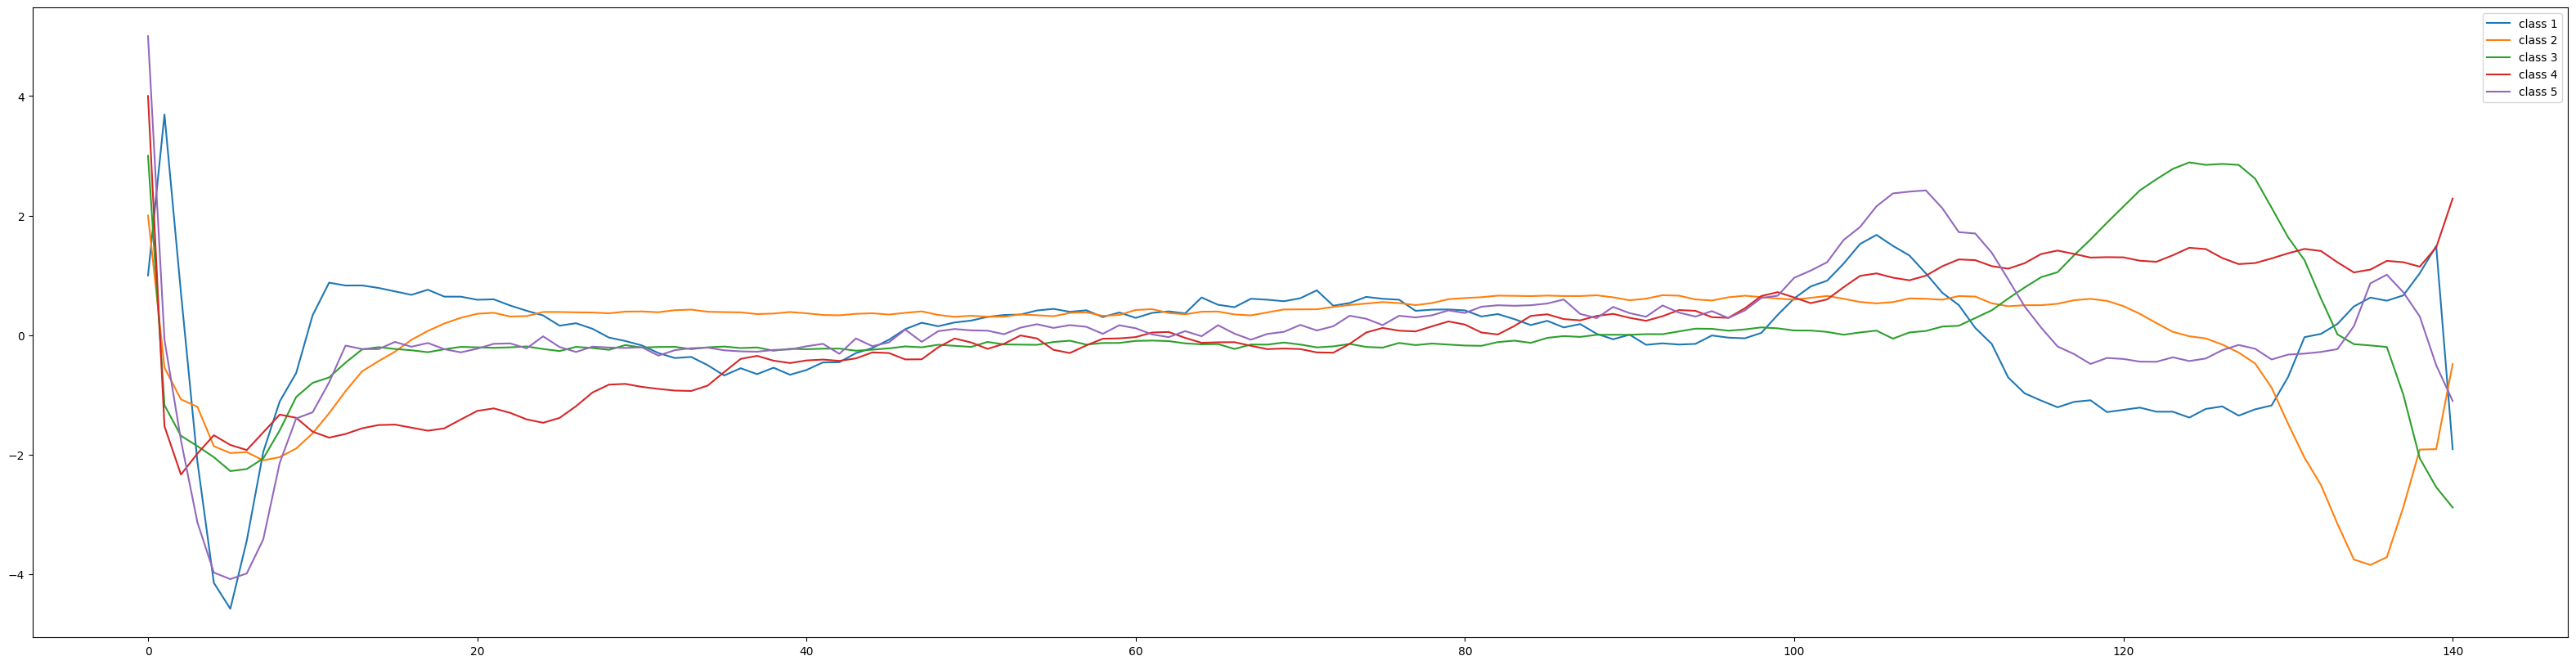

In [8]:
fig, ax = plt.subplots(figsize=(40,10))
ax.plot(test_data[test_data[0]==1].iloc[0, :].values, label='class 1')
ax.plot(test_data[test_data[0]==2].iloc[0, :].values, label='class 2')
ax.plot(test_data[test_data[0]==3].iloc[0, :].values, label='class 3')
ax.plot(test_data[test_data[0]==4].iloc[0, :].values, label='class 4')
ax.plot(test_data[test_data[0]==5].iloc[0, :].values, label='class 5')

ax.legend()

Training Approaches:
- Using convnets
- Approach A: Basic classification
- Approach B: Building a siamese net for pairwise distinction

Approach A:

In [9]:
# because of the nature of the distribution of the classes, i.e. there being more examples in class 1 and 2 and fewer examples in the rest of the classes..going to train on just class 1 and 2
refined_train = test_data[test_data[0].isin([1,2])]
refined_test = train_data[train_data[0].isin([1,2])]

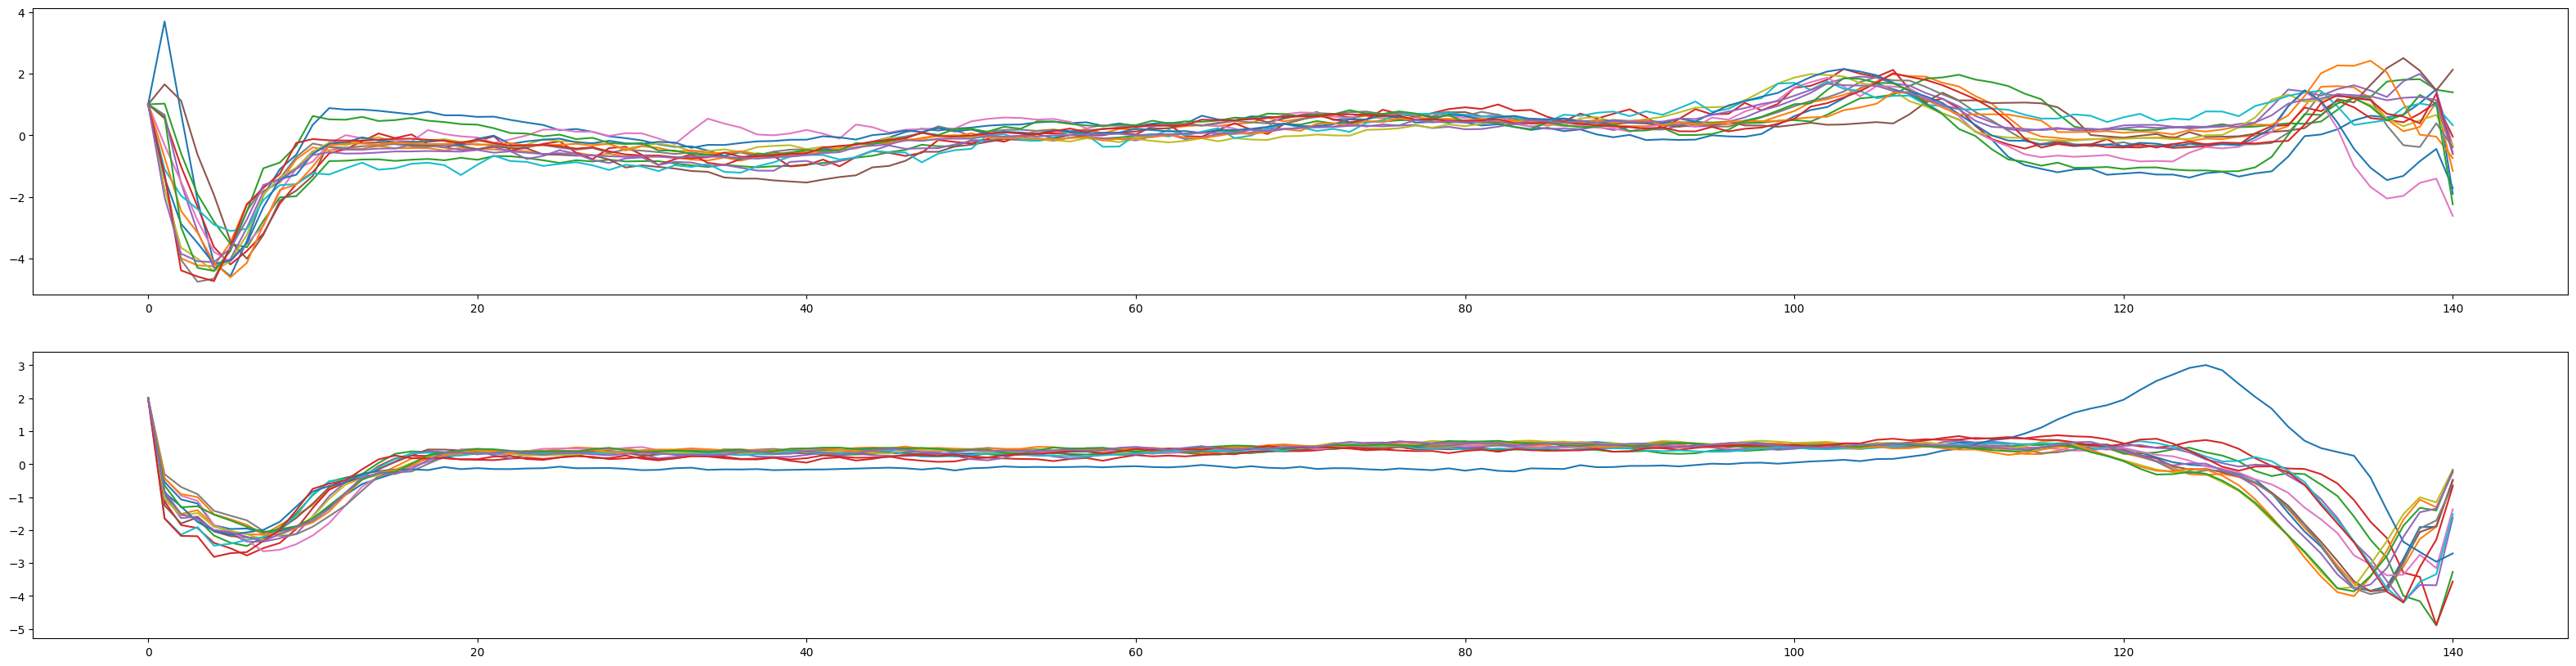

In [10]:
fig, ax = plt.subplots(2,1,figsize=(40,10))

for i in range(15):
    ax[0].plot(refined_train[refined_train[0]==1].iloc[i, :].values)
    ax[1].plot(refined_train[refined_train[0]==2].iloc[i, :].values)

In [11]:
refined_train.shape

(4217, 141)

In [14]:
refined_train.head(3)

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,1,3.690844,0.711414,-2.114091,-4.141007,-4.574472,-3.431909,-1.950791,-1.107067,-0.632322,...,-0.032477,0.022847,0.188937,0.480932,0.629250,0.577291,0.665527,1.035997,1.492287,-1.905073
1,1,-1.348132,-3.996038,-4.226750,-4.251187,-3.477953,-2.228422,-1.808488,-1.534242,-0.779861,...,0.937984,1.570938,1.591394,1.549193,1.193077,0.515134,0.126274,0.267532,1.071148,-1.164009
2,1,1.024295,-0.590314,-1.916949,-2.806989,-3.527905,-3.638675,-2.779767,-2.019031,-1.980754,...,0.368820,0.443502,0.827582,1.237007,1.235121,1.738103,1.800767,1.816301,1.473963,1.389767


In [12]:
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn.functional as F 

In [21]:
from sklearn.model_selection import train_test_split

In [27]:
import torch

In [22]:
refined_train_, refined_val_ = train_test_split(refined_train, test_size=0.2, stratify=refined_train[0])

In [23]:
refined_train_.shape, refined_val_.shape

((3373, 141), (844, 141))

In [32]:
refined_train_[0]

3989    2
1145    1
1551    1
752     1
1775    1
       ..
2424    1
1921    1
2763    2
138     1
889     1
Name: 0, Length: 3373, dtype: int64

In [ ]:
refined_train_.iloc[:, 0].values.shape

(3373, 140)

In [46]:
refined_train_.iloc[:, 1:].values.astype(np.float32).shape

(3373, 140)

In [34]:
refined_train_[0] = refined_train_[0].apply(lambda x: 0 if x==1 else 1)
refined_test[0] = refined_test[0].apply(lambda x: 0 if x==1 else 1)
refined_val_[0] = refined_val_[0].apply(lambda x: 0 if x==1 else 1)

/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_13958/2551110134.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refined_test[0] = refined_test[0].apply(lambda x: 0 if x==1 else 1)


In [62]:
# building the dataset class
class SignalDataset(Dataset):
    def __init__(self, signal_df: pd.DataFrame):
        super().__init__()
        self.data = signal_df.iloc[:, 1:].values.astype(np.float32)
        self.labels = signal_df.iloc[:, 0].values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        return self.data[index],self.labels[index]

In [63]:
train_dataset = SignalDataset(refined_train_)
val_dataset = SignalDataset(refined_val_)
test_dataset = SignalDataset(refined_test)

train_dl = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=64)
test_dl = DataLoader(test_dataset, batch_size=64)

Build a simple model

In [64]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding="same"),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Conv1d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding="same"),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
    
    def forward(self, x):
        return self.conv_block(x)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(
                m.weight
            )
            nn.init.zeros_(
                m.bias
            )

class BasicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(in_channels=1, out_channels=8),
            ConvBlock(in_channels=8, out_channels=16),
            ConvBlock(in_channels=16, out_channels=32),
            ConvBlock(in_channels=32, out_channels=64),
        )

        self.classification_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64,16),
            nn.ReLU(),
            nn.Linear(16,1)
        )
    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classification_head(features)

In [65]:
z = BasicNet()

In [66]:
z(torch.rand(64,1,140)).shape

torch.Size([64, 1])

In [67]:
y = next(iter(train_dl))

In [68]:
y, yy = y

In [69]:
y.unsqueeze(1).shape

torch.Size([64, 1, 140])

In [70]:
yy.shape

torch.Size([64])

In [71]:
from utils.early_stopping import EarlyStopping

In [72]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
model = BasicNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=3, factor=0.5, min_lr=1e-6)

early_stopper = EarlyStopping(
    patience=12,
    min_delta=1e-4,
    checkpoint_path='basic_net.pt',
    restore_best_weights=True
)

def train(epochs):
    train_loss = [0] * epochs
    #train_acc = [0] * epochs
    val_loss = [0] * epochs
    #val_acc = [0] * epochs
    fm_train_loss = [0] * epochs
    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch , y_batch = x_batch.unsqueeze(1).to(device), y_batch.to(device)
            # forward pass

            optimizer.zero_grad()

            out = model(x_batch)
            
            # compute the loss
            loss = criterion(out.squeeze(), y_batch)
            # back propagation
            loss.backward()
            # optimization
            optimizer.step()
                        

            train_loss[epoch]+= loss.item() * y_batch.shape[0]

            #train_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
        
        train_loss[epoch] /= len(train_dl.dataset)
        #train_acc[epoch] /= len(train_dl.dataset)

        # evaluation
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch , y_batch = x_batch.unsqueeze(1).to(device), y_batch.to(device)
            
                # forward pass
                out = model(x_batch)

                loss = criterion(out.squeeze(), y_batch)

                val_loss[epoch] += loss.item() * y_batch.shape[0]

                #val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            val_loss[epoch] /= len(val_dl.dataset)
            #val_acc[epoch] /= len(val_dl.dataset)
        with torch.no_grad():
            for x_batch, y_batch in train_dl:
                x_batch , y_batch = x_batch.unsqueeze(1).to(device), y_batch.to(device)
                
                # forward pass
                out = model(x_batch)

                loss = criterion(out.squeeze(), y_batch)

                fm_train_loss[epoch] += loss.item() * y_batch.shape[0]

                #val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            fm_train_loss[epoch] /= len(train_dl.dataset)
            #val_acc[epoch] /= len(val_dl.dataset)
        
        current_lr = optimizer.param_groups[0]["lr"]
        
        print(f"Epoch: {epoch+1} | Train Loss: {train_loss[epoch]} | FM Train Loss: {fm_train_loss[epoch]} | Val Loss: {val_loss[epoch]} |LR: {current_lr}")

        scheduler.step(val_loss[epoch])
        early_stopper(val_loss[epoch], model, optimizer, epoch)

        if early_stopper.should_stop:
            break
    return train_loss, val_loss

In [73]:
hist = train(40)

Epoch: 1 | Train Loss: 0.4875166739902898 | FM Train Loss: 0.31447186194892596 | Val Loss: 0.3047274000836775 |LR: 0.0003
Metric improved to 0.3047. Checkpoint saved at 0
Epoch: 2 | Train Loss: 0.19918815758915354 | FM Train Loss: 0.12171945198950695 | Val Loss: 0.12181020718756445 |LR: 0.0003
Metric improved to 0.1218. Checkpoint saved at 1
Epoch: 3 | Train Loss: 0.09202810815126013 | FM Train Loss: 0.05898451416571275 | Val Loss: 0.0631401958164728 |LR: 0.0003
Metric improved to 0.0631. Checkpoint saved at 2
Epoch: 4 | Train Loss: 0.04997991936724758 | FM Train Loss: 0.0337823962623222 | Val Loss: 0.0406624118916655 |LR: 0.0003
Metric improved to 0.0407. Checkpoint saved at 3
Epoch: 5 | Train Loss: 0.030848968632159197 | FM Train Loss: 0.02184679923182049 | Val Loss: 0.028215251889485884 |LR: 0.0003
Metric improved to 0.0282. Checkpoint saved at 4
Epoch: 6 | Train Loss: 0.021660137223010772 | FM Train Loss: 0.014406662560522273 | Val Loss: 0.021776913254746892 |LR: 0.0003
Metric impr

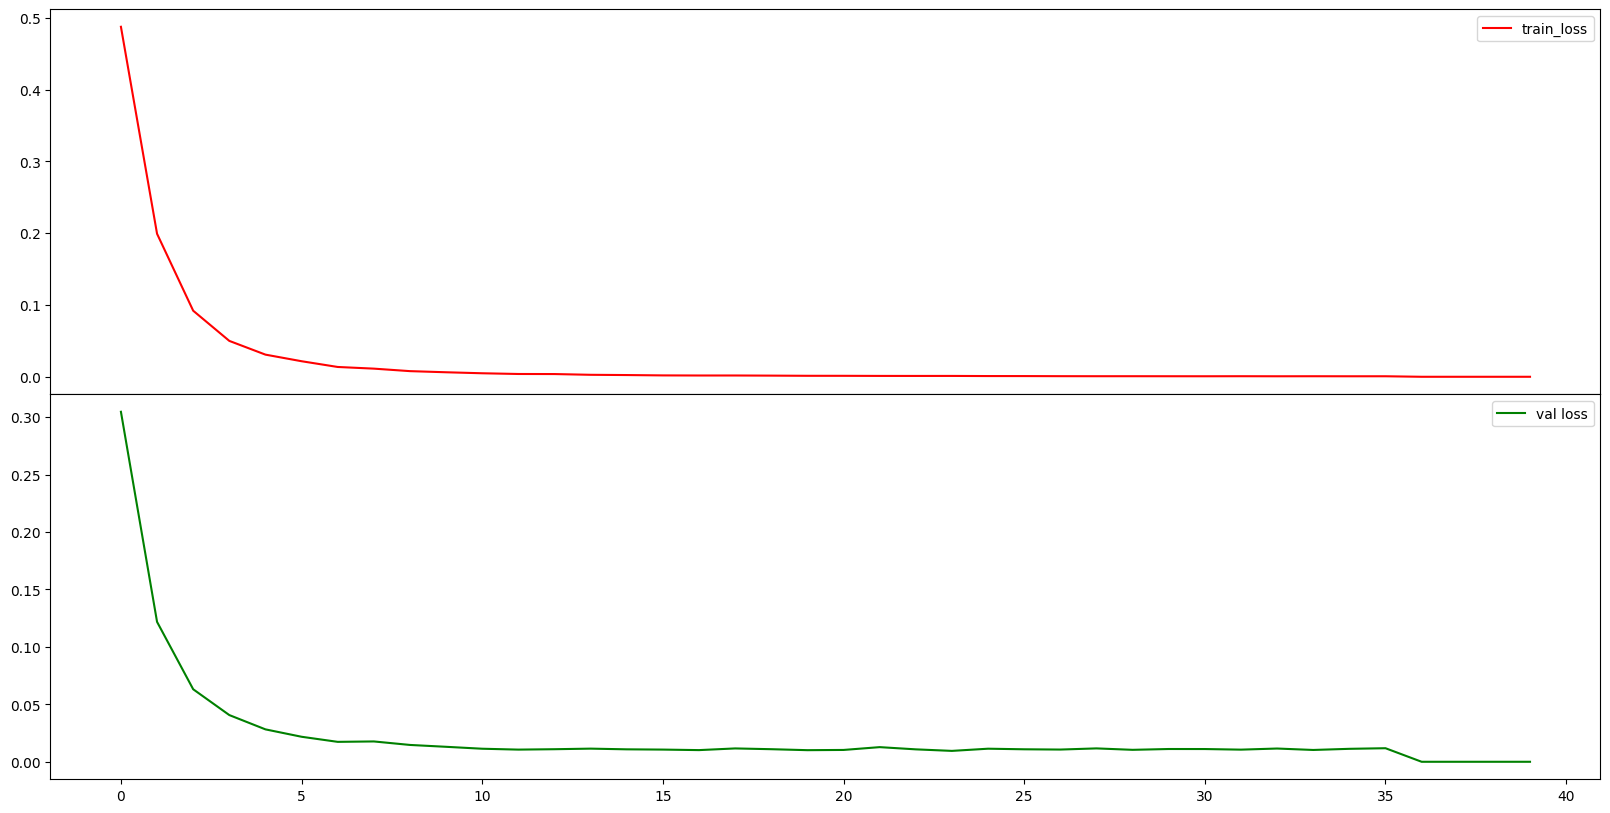

In [74]:
fig, ax = plt.subplots(2,1,figsize=(20,10),sharex=True)
fig.subplots_adjust(hspace=0)
ax[0].plot(hist[:36][0], color='red', label='train_loss')
ax[1].plot(hist[:36][1], color='green', label='val loss')
ax[0].legend(); ax[1].legend()

Test set evaluation

In [75]:
import torch.nn.functional as F

In [76]:
len(test_dl)

8

In [91]:
from sklearn.metrics import accuracy_score, precision_score

In [96]:
test_loss = [0] * len(test_dl)
test_acc = [0] * len(test_dl)
model.eval()
with torch.no_grad():
    for i, (x_batch, y_batch) in enumerate(test_dl):
        x_batch, y_batch = x_batch.unsqueeze(1).to(device), y_batch.to(device)
        out = model(x_batch)
        loss = criterion(out.squeeze(), y_batch)
        test_loss[i] = loss.item() * y_batch.shape[0]

        # compute accuracy
        acc = ((F.sigmoid(out.squeeze()) >= 0.5).float() == y_batch).float().sum()
        print(accuracy_score(y_batch.cpu().clone().numpy().astype(np.int8), (F.sigmoid(out.squeeze()) >= 0.5).cpu().clone().numpy().astype(np.int8)))
        #print(precision_score(y_batch.cpu().clone().numpy().astype(np.int8), (F.sigmoid(out.squeeze()) >= 0.5).cpu().clone().numpy().astype(np.int8), zero_division=0))
        test_acc[i] = acc.item()
    


0.984375
1.0
1.0
0.984375
1.0
1.0
1.0
1.0


In [106]:
np.random.choice?

Signature: np.random.choice(a, size=None, replace=True, p=None)
Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. versionadded:: 1.7.0

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

.. warning::
    This function uses the C-long dtype, which is 32bit on windows
    and otherwise 64bit on 64bit platforms (and 32bit on 32bit ones).
    Since NumPy 2.0, NumPy's default integer is 32bit on 32bit platforms
    and 64bit on 64bit platforms.


Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a


In [107]:
np.random.seed(42)
query_indices = np.random.choice(np.arange(len(test_dataset)), size=10, replace=False)
test_examples = test_dataset[query_indices.tolist()]

In [108]:
query_indices

array([ 55,  73,  33, 445, 425, 229, 210,   9, 352,  70])

In [109]:
test_examples

(array([[-1.0052389 , -2.4362805 , -3.4994445 , ..., -0.23485428,
         -0.18233337, -1.5724036 ],
        [ 1.7537712 ,  0.37744734, -1.5316436 , ..., -0.18520445,
         -0.6623014 , -0.01941774],
        [-0.6571366 , -1.4969218 , -2.0119898 , ...,  1.3749784 ,
          1.587308  ,  1.5575253 ],
        ...,
        [-0.8322811 , -1.7003675 , -2.2573013 , ...,  2.1268518 ,
          1.6792986 ,  0.96581364],
        [ 0.9132484 , -0.10495488, -0.9147156 , ..., -2.7748237 ,
         -2.1804261 , -0.4820698 ],
        [-1.1011347 , -2.5211165 , -3.16029   , ..., -0.8958708 ,
         -1.7159618 , -2.8959768 ]], dtype=float32),
 array([0., 0., 0., 1., 1., 0., 0., 0., 1., 0.], dtype=float32))

In [118]:
test_examples[0][0].shape

(140,)

In [119]:
model.eval()

BasicNet(
  (feature_extractor): Sequential(
    (0): ConvBlock(
      (conv_block): Sequential(
        (0): Conv1d(1, 8, kernel_size=(3,), stride=(1,), padding=same)
        (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv1d(8, 8, kernel_size=(3,), stride=(1,), padding=same)
        (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (conv_block): Sequential(
        (0): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=same)
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
        (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6):

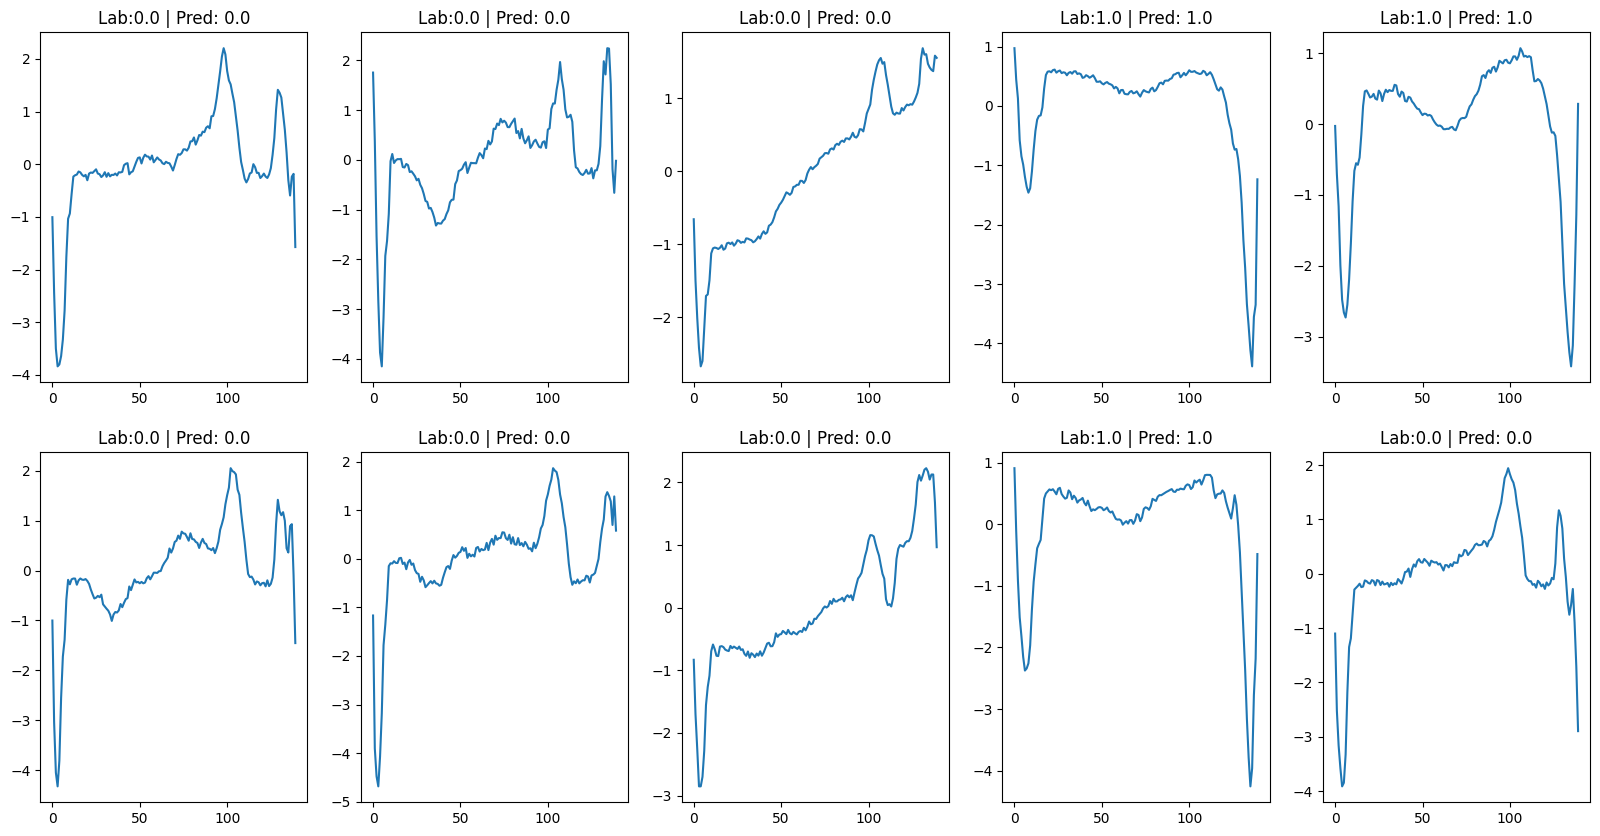

In [122]:
fig, ax  = plt.subplots(2,5, figsize=(20,10))

for i in range(2):
    for j in range(5):
        jj = j if i==0 else 4+j
        ax[i,j].plot(test_examples[0][i+jj])
        with torch.no_grad():
            pred = model(
                torch.tensor(test_examples[0][i+jj]).unsqueeze(0).unsqueeze(1).to(device)
            )
            pred = (F.sigmoid(pred) >= 0.5).float().item()
        ax[i,j].set_title(f"Lab:{test_examples[1][i+jj]} | Pred: {pred}")
